# Homework 2 Advanced Agent
1. Implement Branching Logic
2. Add Long-Term Memory
3. Implement Self-Correction

In [216]:
import os
from typing import Dict, List, Any, Optional, Tuple, TypedDict, Annotated, Union, Literal
from typing_extensions import TypeAlias
import json
from datetime import datetime
import re

# LangChain imports
from langchain_openai import ChatOpenAI
from langchain.prompts import ChatPromptTemplate, MessagesPlaceholder, PromptTemplate
from langchain.schema import SystemMessage, HumanMessage, AIMessage
from langchain.tools import tool
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, FunctionMessage
from langchain_core.output_parsers import StrOutputParser, JsonOutputParser
# from langchain_core.pydantic_v1 import BaseModel, Field
from pydantic import BaseModel, Field

# LangGraph imports
import langgraph as lg
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

In [217]:
from dotenv import load_dotenv, find_dotenv
# Load environment variables (for API keys)
load_dotenv(find_dotenv(), override=True)


True

In [218]:
api_key = os.environ.get("OPENAI_API_KEY")


## Output strutturato
Questa volta useremo un output strutturato con Pydantic

In [219]:
# Define structured output schemas using Pydantic
class RecipeInfo(BaseModel):
    """Information about a recipe"""
    name: str = Field(description="The name of the recipe")
    cuisine: str = Field(description="The cuisine type (e.g., Italian, Mexican, etc.)")
    difficulty: str = Field(description="Difficulty level (Easy, Medium, Hard)")
    prep_time_minutes: int = Field(description="Preparation time in minutes")
    cook_time_minutes: int = Field(description="Cooking time in minutes")
    ingredients: List[str] = Field(description="List of ingredients with quantities")
    instructions: List[str] = Field(description="Step-by-step cooking instructions")
    dietary_info: List[str] = Field(description="Dietary information (e.g., vegetarian, gluten-free)")

class NutritionInfo(BaseModel):
    """Nutrition information for a food item"""
    food_name: str = Field(description="Name of the food item")
    calories_per_serving: int = Field(description="Calories per typical serving")
    protein_grams: float = Field(description="Protein content in grams")
    carbs_grams: float = Field(description="Carbohydrate content in grams")
    fat_grams: float = Field(description="Fat content in grams")
    fiber_grams: float = Field(description="Fiber content in grams")
    key_vitamins: List[str] = Field(description="Key vitamins and minerals")
    serving_size: str = Field(description="Typical serving size")

class UserPreference(BaseModel):
    """User's food preferences and restrictions"""
    dietary_restrictions: List[str] = Field(description="Dietary restrictions (e.g., vegetarian, vegan)")
    allergies: List[str] = Field(description="Food allergies")
    disliked_ingredients: List[str] = Field(description="Ingredients the user dislikes")
    favorite_cuisines: List[str] = Field(description="User's favorite cuisine types")
    cooking_skill: str = Field(description="User's cooking skill level (Beginner, Intermediate, Advanced)")

class AgentAction(BaseModel):
    """Action the agent decides to take"""
    action_type: str = Field(description="Type of action to take (use_tool, respond, clarify, etc.)")
    tool_name: Optional[str] = Field(None, description="Name of the tool to use if action_type is use_tool")
    tool_input: Optional[Any] = Field(None, description="Input for the tool if action_type is use_tool")
    response: Optional[str] = Field(None, description="Direct response if action_type is respond")
    reasoning: str = Field(description="Agent's reasoning for taking this action")

## Gestione della memoria avanzata
Oltre a conservare le conversazioni estrae da esse e mantiene le preferenze utente.

In [220]:
# Define our agent's state with advanced memory
class AgentState(TypedDict):
    # Conversation history
    messages: List[Dict[str, Any]]
    # Current user input
    user_input: str
    # Extracted user preferences
    user_preferences: Dict[str, Any]
    # Agent's current action
    agent_action: Optional[Dict[str, Any]]
    # Tool response if a tool was used
    tool_response: Optional[Any]
    # Structured data from the conversation
    structured_data: Dict[str, Any]
    # Agent's internal thoughts (not shown to user)
    agent_scratchpad: List[str]
    # Final response to user
    final_response: Optional[str]
    
    # Nuovi campimemoria ESERCIZIO 2
    
    important_highlights: Optional[List[str]]
    memory_updated: Optional[bool]  # Flag per monitorare se la memoria è stata aggiornata
    
    
    # Nuovi campi per il routing (esercizio 1)
    routing_path: Optional[List[str]]  # Per tracciare il percorso
    debug: Optional[bool]  # Flag per abilitare il debugging
    trace_routing: Optional[bool]  # Flag per tracciare il routing

In [221]:
# Function to extract conversation context from recent messages
def extract_conversation_context(messages: List[Dict[str, Any]], window_size: int = 5) -> str:
    """Extract the most recent conversation context within a sliding window"""
    recent_messages = messages[-window_size:] if len(messages) > window_size else messages

    context = ""
    for msg in recent_messages:
        role = msg["role"]
        content = msg["content"]
        context += f"{role.capitalize()}: {content}\n\n"

    return context.strip()

In [222]:
# Function to update user preferences based on conversation
def update_user_preferences(state: AgentState) -> Dict[str, Any]:
    """Extract and update user preferences from conversation"""
    # Get existing preferences
    preferences = state.get("user_preferences", {})

    # Get recent conversation context
    recent_context = extract_conversation_context(state["messages"], window_size=10)
    user_input = state["user_input"]

    # Use LLM to extract preferences
    llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)

    prompt = f"""
    Based on the conversation history and current user input, extract or update the user's food preferences.

    Current known preferences: {json.dumps(preferences, indent=2)}

    Recent conversation:
    {recent_context}

    Current user input: {user_input}

    Extract any new or updated preferences related to:
    - Dietary restrictions (vegetarian, vegan, etc.)
    - Allergies
    - Disliked ingredients
    - Favorite cuisines
    - Cooking skill level

    Return ONLY a JSON object with the updated preferences. If no new preferences are found, return the existing preferences.
    """

    try:
        response = llm.invoke(prompt)
        # Extract JSON from response
        json_match = re.search(r'\{[\s\S]*\}', response.content)
        if json_match:
            new_preferences = json.loads(json_match.group(0))
            # Merge with existing preferences
            preferences.update(new_preferences)
    except Exception as e:
        print(f"Error updating preferences: {e}")

    return preferences

# Creiamo gli strumenti per l'agente

In [223]:
# Initialize our language model
llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.7)
# For structured outputs, we'll use a more deterministic model
structured_llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.2)

In [224]:
@tool
def search_recipes(query: str) -> List[Dict[str, Any]]:
    """Search for recipes based on ingredients, cuisine type, or dish name.
    Returns a list of recipe summaries."""

    # In a real application, this would query a recipe database
    prompt = ChatPromptTemplate.from_template(
        """Generate 3 recipe summaries matching this search: {query}.
        For each recipe, include name, cuisine type, difficulty, prep time, and a brief description.
        Format the output as a JSON list of objects with keys: name, cuisine, difficulty, prep_time_minutes, description.
        """
    )

    chain = prompt | structured_llm | JsonOutputParser()
    result = chain.invoke({"query": query})

    return result

@tool
def get_detailed_recipe(recipe_name: str) -> Dict[str, Any]:
    """Get detailed information about a specific recipe including ingredients and instructions."""

    prompt = ChatPromptTemplate.from_template(
        """Generate a detailed recipe for {recipe_name}.
        Include all ingredients with measurements, step-by-step instructions, cooking time, difficulty level, and dietary information.
        Format as a JSON object matching the RecipeInfo schema with these fields:
        name, cuisine, difficulty, prep_time_minutes, cook_time_minutes, ingredients (list), instructions (list), dietary_info (list).
        """
    )

    chain = prompt | structured_llm | JsonOutputParser()
    result = chain.invoke({"recipe_name": recipe_name})

    return result

@tool
def get_nutrition_info(food_item: str) -> Dict[str, Any]:
    """Get detailed nutrition information for a food item or ingredient."""

    prompt = ChatPromptTemplate.from_template(
        """Provide detailed nutrition information for {food_item}.
        Include calories, protein, carbs, fat, fiber, key vitamins/minerals, and typical serving size.
        Format as a JSON object matching the NutritionInfo schema with these fields:
        food_name, calories_per_serving, protein_grams, carbs_grams, fat_grams, fiber_grams, key_vitamins (list), serving_size.
        """
    )

    chain = prompt | structured_llm | JsonOutputParser()
    result = chain.invoke({"food_item": food_item})

    return result

@tool
def generate_meal_plan(requirements: str) -> Dict[str, List[Dict[str, Any]]]:
    """Generate a meal plan based on dietary requirements, preferences, and number of days."""

    prompt = ChatPromptTemplate.from_template(
        """Create a meal plan based on these requirements: {requirements}.
        Include breakfast, lunch, dinner, and snacks for each day.
        Format as a JSON object with days as keys and meals as values.
        Each meal should include name, brief description, and main ingredients.
        """
    )

    chain = prompt | structured_llm | JsonOutputParser()
    result = chain.invoke({"requirements": requirements})

    return result

@tool
def explain_cooking_technique(technique: str) -> Dict[str, Any]:
    """Explain a cooking technique with steps, tips, and example recipes."""

    prompt = ChatPromptTemplate.from_template(
        """Explain the cooking technique: {technique}.
        Include a definition, step-by-step instructions, common mistakes to avoid, and 2-3 example dishes that use this technique.
        Format as a JSON object with keys: technique_name, definition, steps (list), common_mistakes (list), example_dishes (list).
        """
    )

    chain = prompt | structured_llm | JsonOutputParser()
    result = chain.invoke({"technique": technique})

    return result

# Nodi per l'agente

In [225]:
#  Node 1: Context Analysis - Analyzes user input in context of conversation history
def context_analysis_node(state: AgentState) -> AgentState:
    """Analyze user input in the context of conversation history"""
    # Get recent conversation context
    recent_context = extract_conversation_context(state["messages"], window_size=5)
    user_input = state["user_input"]

    # Use LLM to analyze the context
    prompt = ChatPromptTemplate.from_template(
        """Analyze the user's input in the context of the recent conversation.

        Recent conversation:
        {recent_context}

        Current user input: {user_input}

        Provide a brief analysis of:
        1. What is the user's primary intent?
        2. Is this a follow-up to a previous topic? If so, what topic?
        3. Are there any implicit references to previous parts of the conversation?
        4. What key information should be extracted from this input?

        Format your response as a JSON object with keys: primary_intent, is_followup, previous_topic, implicit_references, key_information.
        """
    )

    chain = prompt | structured_llm | JsonOutputParser()
    analysis = chain.invoke({"recent_context": recent_context, "user_input": user_input})

    # Update the agent's scratchpad with this analysis
    state["agent_scratchpad"] = state.get("agent_scratchpad", []) + [f"Context Analysis: {json.dumps(analysis, indent=2)}"]

    # Update structured data
    state["structured_data"] = state.get("structured_data", {})
    state["structured_data"]["context_analysis"] = analysis

    # Update user preferences based on the conversation
    state["user_preferences"] = update_user_preferences(state)

    return state

In [226]:
def action_planning_node(state: AgentState) -> AgentState:
    """Decide what action to take based on context analysis"""
    # Get context analysis
    context_analysis = state["structured_data"].get("context_analysis", {})
    user_preferences = state["user_preferences"]
    user_input = state["user_input"]

    # Verifica se l'utente è confuso PRIMA di utilizzare l'LLM
    confusion_phrases = ["i don't understand", "what do you mean", "confused", "unclear", "explain", "non capisco"]
    is_confused = any(phrase in user_input.lower() for phrase in confusion_phrases)
    
    if is_confused:
        # Se l'utente è confuso, forza l'azione di chiarimento
        action = {
            "action_type": "clarify",
            "response": None,  # Sarà generato dal nodo di chiarimento
            "reasoning": "The user appears confused or is asking for clarification. Providing a detailed explanation."
        }
    else:
        # List available tools
        tools_description = """
        Available tools:
        1. search_recipes(query): Search for recipes based on ingredients, cuisine type, or dish name
        2. get_detailed_recipe(recipe_name): Get detailed information about a specific recipe
        3. get_nutrition_info(food_item): Get nutrition information for a food item
        4. generate_meal_plan(requirements): Generate a meal plan based on requirements
        5. explain_cooking_technique(technique): Explain a cooking technique
        """

        # Use LLM to decide on an action
        prompt = ChatPromptTemplate.from_template(
            """Based on the user input and conversation context, decide what action to take.
            User input: {user_input}
            Context analysis: {context_analysis}
            User preferences: {user_preferences}
            {tools_description}
            Decide on ONE of these actions:
            1. use_tool: Use one of the available tools
            2. respond: Respond directly to the user without using a tool
            3. clarify: Ask for clarification if the user's request is ambiguous
            If choosing use_tool, specify which tool and what input to provide.
            Format your response as a JSON object matching the AgentAction schema with these fields:
            action_type, tool_name (if applicable), tool_input (if applicable), response (if applicable), reasoning
            """
        )

        chain = prompt | structured_llm | JsonOutputParser()
        action = chain.invoke({
            "user_input": user_input,
            "context_analysis": json.dumps(context_analysis, indent=2),
            "user_preferences": json.dumps(user_preferences, indent=2),
            "tools_description": tools_description
        })

    # Update the agent's scratchpad
    state["agent_scratchpad"] = state.get("agent_scratchpad", []) + [f"Action Planning: {json.dumps(action, indent=2)}"]
    
    # Store the action
    state["agent_action"] = action
    
    return state

In [227]:
# Node 3: Tool Execution - Executes the chosen tool if applicable
def tool_execution_node(state: AgentState) -> AgentState:
    """Execute the tool specified in the agent action"""
    action = state["agent_action"]

    # If the action is not to use a tool, skip
    if action["action_type"] != "use_tool" or not action.get("tool_name"):
        return state

    tool_name = action["tool_name"]
    tool_input = action["tool_input"]

    try:
        # Execute the appropriate tool
        if tool_name == "search_recipes":
            result = search_recipes(tool_input)
        elif tool_name == "get_detailed_recipe":
            result = get_detailed_recipe(tool_input)
        elif tool_name == "get_nutrition_info":
            result = get_nutrition_info(tool_input)
        elif tool_name == "generate_meal_plan":
            result = generate_meal_plan(tool_input)
        elif tool_name == "explain_cooking_technique":
            result = explain_cooking_technique(tool_input)
        else:
            result = {"error": f"Unknown tool: {tool_name}"}
    except Exception as e:
        result = {"error": f"Error executing {tool_name}: {str(e)}"}

    # Store the tool response
    state["tool_response"] = result

    # Update the agent's scratchpad
    state["agent_scratchpad"] = state.get("agent_scratchpad", []) + [f"Tool Execution ({tool_name}): {json.dumps(result, indent=2)}"]

    return state

In [228]:
# Node 4: Response Generation - Creates the final response to the user
def response_generation_node(state: AgentState) -> AgentState:
    """Generate the final response to the user"""
    action = state["agent_action"]
    user_preferences = state["user_preferences"]

    # If the action is a direct response, use that
    if action["action_type"] == "respond" and action.get("response"):
        response = action["response"]
    # If the action is to clarify, use the clarification question
    elif action["action_type"] == "clarify" and action.get("response"):
        response = action["response"]
    # If a tool was used, format the tool response
    elif action["action_type"] == "use_tool" and state.get("tool_response"):
        tool_name = action["tool_name"]
        tool_result = state["tool_response"]

        # Use LLM to format the tool result into a natural response
        prompt = ChatPromptTemplate.from_template(
            """Format the following tool result into a natural, conversational response.

            Tool used: {tool_name}
            Tool result: {tool_result}
            User preferences: {user_preferences}

            Create a helpful, friendly response that presents the information clearly.
            If the tool result contains errors, acknowledge them and offer alternatives.
            Tailor your response to match the user's preferences when relevant.

            Response:
            """
        )

        chain = prompt | llm | StrOutputParser()
        response = chain.invoke({
            "tool_name": tool_name,
            "tool_result": json.dumps(tool_result, indent=2),
            "user_preferences": json.dumps(user_preferences, indent=2)
        })
    else:
        # Fallback response if something went wrong
        response = "I'm not sure how to respond to that. Could you rephrase your question?"

    # Store the final response
    state["final_response"] = response

    # Update the conversation history
    state["messages"].append({"role": "human", "content": state["user_input"]})
    state["messages"].append({"role": "ai", "content": response})

    return state

In [229]:
# Node 5: Self-Reflection - Analyzes the agent's performance and learns from it
def self_reflection_node(state: AgentState) -> AgentState:
    """Reflect on the agent's performance and update internal knowledge"""
    # This would be more sophisticated in a production system
    # For now, we'll just log some information

    action = state["agent_action"]
    final_response = state["final_response"]

    # Use LLM to reflect on the interaction
    prompt = ChatPromptTemplate.from_template(
        """Reflect on this interaction:

        User input: {user_input}
        Action taken: {action}
        Final response: {final_response}

        Provide a brief reflection on:
        1. Was this the optimal action for the user's request?
        2. Could the response be improved? How?
        3. What should be remembered for future interactions with this user?

        Format your response as a JSON object with keys: optimal_action, improvement_suggestions, future_considerations.
        """
    )

    chain = prompt | structured_llm | JsonOutputParser()
    reflection = chain.invoke({
        "user_input": state["user_input"],
        "action": json.dumps(action, indent=2),
        "final_response": final_response
    })

    # ESERCIZIO 2: analisi per l'estrazione di informazioni importanti
    # Update the agent's scratchpad
    state["agent_scratchpad"] = state.get("agent_scratchpad", []) + [f"Self-Reflection: {json.dumps(reflection, indent=2)}"]

    # Store the reflection in structured data
    state["structured_data"] = state.get("structured_data", {})
    state["structured_data"]["reflection"] = reflection

    # Estrazione migliorata di informazioni importanti
    important_info = identify_important_info(state)
    

    # Salva le informazioni importanti nella memoria
    if important_info:
        if "important_highlights" not in state or state["important_highlights"] is None:
            state["important_highlights"] = [important_info]
        else:
            state["important_highlights"].append(important_info)
        
        # Imposta il flag di aggiornamento della memoria
        state["memory_updated"] = True

    return state

##  Grafo

In [230]:
# Create the workflow graph
workflow = StateGraph(AgentState)

# Add our nodes to the graph
workflow.add_node("context_analysis", context_analysis_node)
workflow.add_node("action_planning", action_planning_node)
workflow.add_node("tool_execution", tool_execution_node)
workflow.add_node("response_generation", response_generation_node)
workflow.add_node("self_reflection", self_reflection_node)

# Define the flow between nodes
workflow.set_entry_point("context_analysis")
workflow.add_edge("context_analysis", "action_planning")
workflow.add_edge("action_planning", "tool_execution")
workflow.add_edge("tool_execution", "response_generation")
workflow.add_edge("response_generation", "self_reflection")
workflow.add_edge("self_reflection", END)

# Compile the graph into a runnable agent
advanced_recipe_agent = workflow.compile()

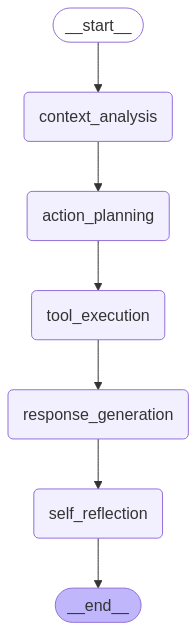

In [231]:
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

display(
    Image(
        advanced_recipe_agent.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

## Interfaccia Chat

In [232]:
class ChatSession:
    """A class to manage chat sessions with our advanced agent"""

    def __init__(self, user_id: str = "default_user"):
        """Initialize a new chat session"""
        self.messages = []
        self.user_preferences = {}
        self.structured_data = {}
        ## Inizializzo la memoria persistnete (ESERCIZIO 2)
        self.memory = PersistentMemory(user_id)
        # Carica le preferenze utente dalla memoria
        self.user_preferences = self.memory.get_preferences()
        # Aggiungi riferimento all'ultima sessione se esiste
        if self.memory.memory["last_session"]:
            # Potrebbe essere utile caricare anche messaggi precedenti
            last_highlights = self.memory.get_conversation_highlights()
            if last_highlights:
                # Opzionale: aggiungi un messaggio di riepilogo delle conversazioni precedenti
                summary = self._create_session_summary(last_highlights)
                if summary:
                    self.messages.append({"role": "system", "content": summary})
    # memoria persistnete (ESERCIZIO 2)
    def _create_session_summary(self, highlights):
        """Create a more comprehensive summary of previous conversations"""
        if not highlights:
            return None
        
        # Raggruppa gli highlights per categoria se possibile
        dietary_info = []
        preferences = []
        other_info = []
        
        for highlight in highlights:
            content = highlight['content']
            if any(term in content.lower() for term in ['vegetarian', 'vegan', 'allergy', 'allergic']):
                dietary_info.append(content)
            elif any(term in content.lower() for term in ['like', 'love', 'prefer', 'favorite']):
                preferences.append(content)
            else:
                other_info.append(content)
        
        # Crea un riepilogo strutturato
        summary = "From our previous conversations, I recall:\n\n"
        
        if dietary_info:
            summary += "Dietary Information:\n"
            for info in dietary_info[-2:]:  # Ultimi 2 elementi
                summary += f"- {info}\n"
            summary += "\n"
        
        if preferences:
            summary += "Preferences:\n"
            for pref in preferences[-2:]:  # Ultimi 2 elementi
                summary += f"- {pref}\n"
            summary += "\n"
        
        if other_info:
            summary += "Other Information:\n"
            for info in other_info[-2:]:  # Ultimi 2 elementi
                summary += f"- {info}\n"
        
        return summary
    
    
    def chat(self, user_input: str, debug: bool = False, trace_routing: bool = False) -> str:
        """Process a user message and get the agent's response"""
        # Initialize the agent state
        state = {
            "messages": self.messages,
            "user_input": user_input,
            "user_preferences": self.user_preferences,
            "agent_action": None,
            "tool_response": None,
            "structured_data": self.structured_data,
            "agent_scratchpad": [],
            "final_response": None,
            ##Aggiungo tracciamento ROUTE ESERCIZIO 1
            "routing_path": [],  # Inizializza il percorso di routing
            "debug": debug,  # Passa il flag di debug
            "trace_routing": trace_routing  # Passa il flag di tracciamento
        }
    
        # Print start of workflow if tracing routing
        if trace_routing:
            print("\n--- Starting Agent Workflow ---")
    
        # Run the agent
        result = advanced_recipe_agent.invoke(state)

        ## ESERCIZIO 2
        # Verifica se ci sono elementi importanti da salvare come highlights
        if "important_highlights" in result and result["important_highlights"]:
            for highlight in result["important_highlights"]:
                self.add_highlight(highlight)
        
        # Aggiorna la memoria con le nuove preferenze utente
        if result["user_preferences"] != self.user_preferences:
            self.memory.update_preferences(result["user_preferences"])
        
        # Aggiorna la sessione corrente
        self.memory.memory["last_session"] = {
            "timestamp": datetime.now().isoformat(),
            "last_message": user_input
        }
        self.memory.save_memory()
    
        # Update session state
        self.messages = result["messages"]
        self.user_preferences = result["user_preferences"]
        self.structured_data = result["structured_data"]

        # Print debug information if requested
        if debug:
            print("\n=== DEBUG INFORMATION ===")
        
            # Mostra l'azione pianificata dall'agente
            print("\nAgent Action:")
            print(json.dumps(result.get("agent_action", {}), indent=2))
        
            # Mostra la risposta dello strumento, se presente
            if result.get("tool_response"):
                print("\nTool Response:")
                print(json.dumps(result.get("tool_response", {}), indent=2))
        
            # Mostra l'analisi del contesto, se presente
            if result.get("structured_data", {}).get("context_analysis"):
                print("\nContext Analysis:")
                print(json.dumps(result["structured_data"]["context_analysis"], indent=2))
        
            # Mostra lo scratchpad dell'agente
            print("\nAgent Scratchpad:")
            for note in result["agent_scratchpad"]:
                print(f"\n{note}")
        
            # Mostra le preferenze dell'utente
            print("\nUser Preferences:")
            print(json.dumps(self.user_preferences, indent=2))
        
            # Mostra il percorso seguito dal grafo
            if "routing_path" in result:
                print("\nRouting Path:")
                print(" -> ".join(result["routing_path"]))
                

            # ESERCIZIO 2 Debug memoria
            print("\nPersistent Memory:")
            print("Last session:", json.dumps(self.memory.memory.get("last_session", {}), indent=2))
            print("\nConversation Highlights:")
            for highlight in self.memory.get_conversation_highlights()[-3:]:  # mostra gli ultimi 3
                print(f"- {highlight['timestamp']}: {highlight['content']}")
        
            print("\n=== END DEBUG INFORMATION ===\n")

            
            
    
        # Print end of workflow if tracing routing
        if trace_routing:
            print("--- Workflow Complete ---\n")

        return result["final_response"]

    # ESERCIZIO 2 metodo per salvare punti importanti della conversazione
    def add_highlight(self, content: str):
        """Add an important conversation highlight"""
        self.memory.add_conversation_highlight(content)

    def get_conversation_history(self) -> List[Dict[str, str]]:
        """Get the conversation history"""
        return self.messages

    def get_user_preferences(self) -> Dict[str, Any]:
        """Get the user preferences"""
        return self.user_preferences

In [233]:
def interactive_chat(debug: bool = False):
    """Interactive chat with our advanced recipe agent"""
    session = ChatSession()

    print("Welcome to Chef GPT Advanced! Type 'exit' to end the conversation or 'debug' to toggle debug mode.")
    # ESERCIZIO 2 Se ci sono preferenze utente salvate, mostrare un messaggio personalizzato
    if session.user_preferences:
        prefs = session.user_preferences
        welcome_msg = "Welcome back! "
        
        if "dietary_restrictions" in prefs and prefs["dietary_restrictions"]:
            welcome_msg += f"I remember you follow a {', '.join(prefs['dietary_restrictions'])} diet. "
            
        if "favorite_cuisines" in prefs and prefs["favorite_cuisines"]:
            welcome_msg += f"You enjoy {', '.join(prefs['favorite_cuisines'])} cuisine. "
            
        print(welcome_msg)
    print("What cooking questions can I help you with today?")

    while True:
        user_input = input("\nYou: ")

        if user_input.lower() == 'exit':
            print("\nChef GPT: Goodbye! Happy cooking!")
            # ESERCIZIO 2 Salva lo stato finale della sessione
            session.memory.memory["last_session"]["ended_at"] = datetime.now().isoformat()
            session.memory.save_memory()
            break
        elif user_input.lower() == 'debug':
            debug = not debug
            print(f"\nDebug mode {'enabled' if debug else 'disabled'}")
            continue

        response = session.chat(user_input, debug)
        print(f"\nChef GPT: {response}")

        # ESERCIZIO 2 Controlla se ci sono informazioni importanti da salvare
        if hasattr(session, "important_highlights") and session.important_highlights:
            for highlight in session.important_highlights:
                session.add_highlight(highlight)

In [32]:
interactive_chat()

Welcome to Chef GPT Advanced! Type 'exit' to end the conversation or 'debug' to toggle debug mode.
What cooking questions can I help you with today?



You:  i would like to prepare some lasagna



Chef GPT: Based on your favorite cuisine of Italian, here are some delicious lasagna recipes you might enjoy:

1. Classic Italian Lasagna:
- Cuisine: Italian
- Difficulty: Intermediate
- Prep Time: 60 minutes
- Description: Layers of lasagna noodles, meat sauce, ricotta cheese, and mozzarella baked to perfection for a classic Italian comfort food dish.

2. Vegetarian Spinach and Mushroom Lasagna:
- Cuisine: Italian
- Difficulty: Intermediate
- Prep Time: 75 minutes
- Description: A delicious twist on traditional lasagna with layers of spinach, mushrooms, ricotta cheese, and marinara sauce for a hearty and satisfying vegetarian meal.

If you're looking for a different twist on lasagna, you might also enjoy the Mexican Style Enchilada Lasagna:
- Cuisine: Mexican
- Difficulty: Intermediate
- Prep Time: 90 minutes
- Description: A fusion of Mexican and Italian flavors with layers of corn tortillas, seasoned ground beef, salsa, and cheese for a unique and flavorful twist on traditional las


You:  exit



Chef GPT: Goodbye! Happy cooking!


## Sessioni con follow up

In [33]:
# Create a test session
test_session = ChatSession()

# Test 1: Initial greeting and preference gathering
response = test_session.chat("Hi! I'm looking for some healthy dinner ideas. I'm vegetarian and trying to eat more protein.")
print("Test 1 - Initial greeting with preferences")
print(f"User: Hi! I'm looking for some healthy dinner ideas. I'm vegetarian and trying to eat more protein.")
print(f"Agent: {response}")
print("\n" + "-"*50 + "\n")

Test 1 - Initial greeting with preferences
User: Hi! I'm looking for some healthy dinner ideas. I'm vegetarian and trying to eat more protein.
Agent: Based on your dietary restrictions and cooking skill level, here are some vegetarian recipes you might enjoy:

1. Quinoa Stuffed Bell Peppers:
- Cuisine: American
- Difficulty: Medium
- Prep Time: 45 minutes
- Description: These bell peppers are filled with a mixture of quinoa, black beans, corn, and spices, making them a delicious and protein-packed vegetarian dinner option.

2. Chickpea and Spinach Curry:
- Cuisine: Indian
- Difficulty: Easy
- Prep Time: 30 minutes
- Description: This flavorful curry is made with chickpeas, spinach, tomatoes, and a blend of Indian spices. It's a quick and easy vegetarian dinner that is high in protein.

3. Lentil Shepherd's Pie:
- Cuisine: British
- Difficulty: Medium
- Prep Time: 60 minutes
- Description: This vegetarian twist on a classic shepherd's pie features a hearty lentil and vegetable filling t

In [34]:
# Test 2: Follow-up question with context
response = test_session.chat("Can you give me a specific recipe for one of those options?")
print("Test 2 - Follow-up with context")
print(f"User: Can you give me a specific recipe for one of those options?")
print(f"Agent: {response}")
print("\n" + "-"*50 + "\n")

Test 2 - Follow-up with context
User: Can you give me a specific recipe for one of those options?
Agent: Based on your preferences as a vegetarian with intermediate cooking skills, here are some recipe suggestions for you:

1. Quinoa Stuffed Bell Peppers (American cuisine) - A medium difficulty dish that takes 45 minutes to prepare. These bell peppers are filled with a mixture of quinoa, black beans, corn, and spices, making it a delicious and protein-packed vegetarian dinner option.

2. Chickpea and Spinach Curry (Indian cuisine) - An easy dish that takes 30 minutes to prepare. This flavorful curry is made with chickpeas, spinach, tomatoes, and a blend of aromatic spices. It's a quick and easy high-protein dinner option for vegetarians.

3. Lentil Shepherd's Pie (British cuisine) - A medium difficulty dish that takes 60 minutes to prepare. This vegetarian twist on a classic shepherd's pie features a hearty lentil and vegetable filling topped with creamy mashed potatoes. It's a comfort

In [35]:
# Test 3: Nutrition information request
response = test_session.chat("What's the nutritional value of tofu?")
print("Test 3 - Nutrition information")
print(f"User: What's the nutritional value of tofu?")
print(f"Agent: {response}")
print("\n" + "-"*50 + "\n")

Test 3 - Nutrition information
User: What's the nutritional value of tofu?
Agent: Hey there! I found some nutrition information for Tofu for you. In a 100-gram serving, Tofu has 94 calories, 10 grams of protein, 2 grams of carbs, 6 grams of fat, and 1 gram of fiber. It's also a good source of key vitamins like Calcium, Iron, and Magnesium. 

Since you have a vegetarian dietary restriction, Tofu is a great option for you! It's a versatile ingredient that can be used in many cuisines, and with your intermediate cooking skill level, you can explore different ways to incorporate it into your meals. 

If you have any specific preferences or questions about Tofu or other ingredients, feel free to let me know!

--------------------------------------------------



In [36]:
# Let's examine what the agent has learned about the user
print("User Preferences Learned:")
print(json.dumps(test_session.get_user_preferences(), indent=2))

User Preferences Learned:
{
  "Dietary restrictions": [
    "vegetarian"
  ],
  "Favorite cuisines": [],
  "Disliked ingredients": [],
  "Allergies": [],
  "Cooking skill level": "Intermediate"
}


# Exercise 1 Implement branching logic
Modify the agent graph to include conditional branching based on the action type. For example, if the action is "clarify", route to a special clarification node before generating a response.

- Funzione per l'azione di route per capire verso quale nodo andare
- Nodo per i chiarimenti
- aggiungere il nodo al workflow
- aggiungo alla classe `AgentState` i paramettri per il routing##
- Quando inzializzo a sessione di chat, nello stato devo passare le nuove informazioni
- aggiungo il nodo anche alla classe `action_planning_node`

In [234]:
def route_action(state: AgentState) -> str:
    action_type = state["agent_action"]["action_type"]
    
    if action_type == "use_tool":
        route = "tool_execution"
    elif action_type == "clarify":
        route = "clarification"
    else:  # respond
        route = "response_generation"
    
    # Sempre registra il percorso, non solo in modalità debug
    state["routing_path"] = state.get("routing_path", []) + [f"action_planning -> {route}"]
    
    if state.get("debug", False) or state.get("trace_routing", False):
        print(f"DEBUG: Routing from action_planning to {route}")
    
    return route

# Nod per i chiarimenti
Cerco di far capire al modello i segnali di possibile confusione dell'utente o se va approfondito un concetto. Quindi dando delle parole che fanno scattare lo stato di confusione dell'utente. Gli chiedo quindi di guardare le precedenti conversazioni per capire cosa può avere confuso l'utente.

In [235]:
def clarification_node(state: AgentState) -> AgentState:
    """Handle clarification requests from the agent or confusion from the user"""
    action = state["agent_action"]
    user_input = state["user_input"]
    user_preferences = state["user_preferences"]
    
    # Check if the user is expressing confusion or lack of understanding
    user_confusion_indicators = ["i don't understand", "what do you mean", "confused", "unclear", "explain again"]
    user_is_confused = any(indicator in user_input.lower() for indicator in user_confusion_indicators)
    
    if user_is_confused:
        # Handle user confusion by providing a more detailed explanation
        prompt = ChatPromptTemplate.from_template(
            """The user has indicated they don't understand something. 
            
            Recent conversation history: {conversation_history}
            
            User's message indicating confusion: {user_input}
            
            Provide a clear, helpful explanation that addresses their confusion. 
            Break down complex concepts if needed and offer examples.
            
            Response:
            """
        )
        
        # Get recent conversation context to understand what might be confusing
        recent_context = extract_conversation_context(state["messages"], window_size=3)
        
        chain = prompt | llm | StrOutputParser()
        explanation_response = chain.invoke({
            "conversation_history": recent_context,
            "user_input": user_input
        })
        
        state["final_response"] = explanation_response
    else:
        # Regular clarification request from the agent
        if action.get("response"):
            clarification_question = action["response"]
        else:
            prompt = ChatPromptTemplate.from_template(
                """Generate a polite clarification question based on the user's input.
                
                User input: {user_input}
                
                User preferences: {user_preferences}
                
                The user's request is ambiguous or missing details. Create a specific question that will 
                help you better understand what they're looking for. Be friendly and conversational.
                
                Clarification question:
                """
            )
            
            chain = prompt | llm | StrOutputParser()
            clarification_question = chain.invoke({
                "user_input": user_input,
                "user_preferences": json.dumps(user_preferences, indent=2)
            })
        
        state["final_response"] = clarification_question
    
    # Update the conversation history
    state["messages"].append({"role": "human", "content": user_input})
    state["messages"].append({"role": "ai", "content": state["final_response"]})
    
    # Update the agent's scratchpad
    state["agent_scratchpad"] = state.get("agent_scratchpad", []) + [
        f"Clarification: {state['final_response']}"
    ]
    
    return state

## Creo il nuovo workflow

In [236]:
# 1. Aggiungere il nuovo nodo al grafo
workflow = StateGraph(AgentState)

# Aggiungi i nodi esistenti
workflow.add_node("context_analysis", context_analysis_node)
workflow.add_node("action_planning", action_planning_node)
workflow.add_node("tool_execution", tool_execution_node)
workflow.add_node("response_generation", response_generation_node)
workflow.add_node("self_reflection", self_reflection_node)

# Aggiungi il nuovo nodo per la chiarificazione
workflow.add_node("clarification", clarification_node)

# 2. Impostare il punto di entrata
workflow.set_entry_point("context_analysis")

# 3. Definire i percorsi normali
workflow.add_edge("context_analysis", "action_planning")

# 4. Aggiungere percorsi condizionali basati sulla decisione dell'azione
workflow.add_conditional_edges(
    "action_planning",
    route_action,
    {
        "tool_execution": "tool_execution",
        "clarification": "clarification",
        "response_generation": "response_generation"
    }
)

# 5. Completare i percorsi rimanenti
workflow.add_edge("tool_execution", "response_generation")
workflow.add_edge("clarification", "response_generation")
workflow.add_edge("response_generation", "self_reflection")
workflow.add_edge("self_reflection", END)

# Compilare il grafo
advanced_recipe_agent = workflow.compile()

In [ ]:
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

display(
    Image(
        advanced_recipe_agent.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

Non funziona prova a copiarlo da loro live editor https://mermaid.live/

In [92]:
mermaid_code = advanced_recipe_agent.get_graph().draw_mermaid()
print(mermaid_code)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	context_analysis(context_analysis)
	action_planning(action_planning)
	tool_execution(tool_execution)
	response_generation(response_generation)
	self_reflection(self_reflection)
	clarification(clarification)
	__end__([<p>__end__</p>]):::last
	__start__ --> context_analysis;
	clarification --> response_generation;
	context_analysis --> action_planning;
	response_generation --> self_reflection;
	self_reflection --> __end__;
	tool_execution --> response_generation;
	action_planning -.-> tool_execution;
	action_planning -.-> clarification;
	action_planning -.-> response_generation;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



![grafo nuovo workflow](mermaid_chart.png)

In [112]:
# Test per il nodo di chiarificazione avanzato
test_clarification_session = ChatSession()

# Test per la rilevazione della confusione dell'utente
print("Test - Utente confuso")
# Prima stabilisci un contesto
test_clarification_session.chat("How i cook carbonara?" , debug=True, trace_routing=True)

Test - Utente confuso

--- Starting Agent Workflow ---
DEBUG: Routing from action_planning to tool_execution

=== DEBUG INFORMATION ===

Agent Action:
{
  "action_type": "use_tool",
  "tool_name": "search_recipes",
  "tool_input": "carbonara recipe",
  "reasoning": "The user is seeking information on how to cook carbonara, so searching for a carbonara recipe will provide the step-by-step process."
}

Tool Response:
[
  {
    "name": "Classic Spaghetti Carbonara",
    "cuisine": "Italian",
    "difficulty": "Intermediate",
    "prep_time_minutes": 30,
    "description": "This classic Italian dish features spaghetti tossed in a creamy sauce made with eggs, cheese, pancetta, and black pepper. It's a comforting and satisfying meal that is perfect for a cozy night in."
  },
  {
    "name": "Carbonara with a Twist",
    "cuisine": "Fusion",
    "difficulty": "Intermediate",
    "prep_time_minutes": 40,
    "description": "Put a twist on the traditional carbonara recipe by adding some unique 

'Here are some recipes you might like based on your favorite cuisine of Italian:\n\n1. Classic Spaghetti Carbonara\n   - Cuisine: Italian\n   - Difficulty: Intermediate\n   - Prep Time: 30 minutes\n   - Description: A comforting dish featuring spaghetti in a creamy sauce with eggs, cheese, pancetta, and black pepper.\n\n2. Carbonara with a Twist\n   - Cuisine: Fusion\n   - Difficulty: Intermediate\n   - Prep Time: 40 minutes\n   - Description: A unique twist on traditional carbonara with mushrooms, peas, and truffle oil for a fusion of rich flavors.\n\n3. Lightened-Up Carbonara\n   - Cuisine: Healthy\n   - Difficulty: Easy\n   - Prep Time: 25 minutes\n   - Description: A healthier version of carbonara using turkey bacon, Greek yogurt, and whole wheat pasta for a guilt-free meal option.\n\nFeel free to try one of these recipes for a delicious Italian-inspired meal! Let me know if you need more information or have any other preferences.'

In [113]:
# Poi testa la confusione
response = test_clarification_session.chat("I don't understand 'pasta alla carbonara'?", debug=True, trace_routing=True)
print(f"User: Non capisco, cosa intendi con 'pasta alla carbonara'?")
print(f"Agent: {response}")
print("\n" + "-"*50 + "\n")


--- Starting Agent Workflow ---
DEBUG: Routing from action_planning to clarification

=== DEBUG INFORMATION ===

Agent Action:
{
  "action_type": "clarify",
  "response": null,
  "reasoning": "The user appears confused or is asking for clarification. Providing a detailed explanation."
}

Context Analysis:
{
  "primary_intent": "Seeking clarification on the dish 'pasta alla carbonara'",
  "is_followup": true,
  "previous_topic": "Cooking carbonara",
  "implicit_references": "The user is referencing the previous conversation about cooking carbonara",
  "key_information": "User is seeking understanding or explanation of the dish 'pasta alla carbonara'"
}

Agent Scratchpad:

Context Analysis: {
  "primary_intent": "Seeking clarification on the dish 'pasta alla carbonara'",
  "is_followup": true,
  "previous_topic": "Cooking carbonara",
  "implicit_references": "The user is referencing the previous conversation about cooking carbonara",
  "key_information": "User is seeking understanding o

## FInalmente ha capito che dall'action planning deve andare alla clarification!!!
```
-- Starting Agent Workflow ---
DEBUG: Routing from action_planning to clarification

=== DEBUG INFORMATION ===

Agent Action:
{
  "action_type": "clarify",
  "response": null,
  "reasoning": "The user appears confused or is asking for clarification. Providing a detailed explanation."
}
    ```

# Exercise 2 Add Long-Term Memory

Implement a persistent storage mechanism to remember user preferences and conversation highlights across sessions.

- Modifico nuovamente la classe `ChatSession`per usare il nuovo metodo
- Modificare il `self_reflection_node` per identificare info importante
- `interactive_chat` crea una sessione con ID utente
- `AgentState` dve essere aggiornato con i nuovi campi

In [237]:
import json
import os

class PersistentMemory:
    """A class to manage persistent memory across sessions"""

    def __init__(self, user_id: str, storage_dir: str = "./memory"):
        self.user_id = user_id
        self.storage_dir = storage_dir
        self.file_path = f"{storage_dir}/{user_id}.json"

        # Create storage directory if it doesn't exist
        os.makedirs(storage_dir, exist_ok=True)

        # Initialize or load memory
        self.memory = self._load_memory()

    def _load_memory(self) -> Dict[str, Any]:
        """Load memory from storage"""
        if os.path.exists(self.file_path):
            with open(self.file_path, 'r') as f:
                return json.load(f)
        else:
            return {
                "user_preferences": {},
                "conversation_highlights": [],
                "last_session": None
            }

    def save_memory(self):
        """Save memory to storage"""
        with open(self.file_path, 'w') as f:
            json.dump(self.memory, f, indent=2)

    def update_preferences(self, new_preferences: Dict[str, Any]):
        """Update user preferences"""
        self.memory["user_preferences"].update(new_preferences)
        self.save_memory()

    def add_conversation_highlight(self, highlight: str):
        """Add an important conversation highlight"""
        self.memory["conversation_highlights"].append({
            "timestamp": datetime.now().isoformat(),
            "content": highlight
        })
        self.save_memory()

    def get_preferences(self) -> Dict[str, Any]:
        """Get user preferences"""
        return self.memory["user_preferences"]

    def get_conversation_highlights(self) -> List[Dict[str, str]]:
        """Get conversation highlights"""
        return self.memory["conversation_highlights"]

In [246]:
def identify_important_info(state: AgentState) -> Optional[str]:
    """Identificazione migliorata di informazioni importanti dalla conversazione"""
    user_input = state["user_input"]
    final_response = state["final_response"]
    current_preferences = state.get("user_preferences", {})
    
    # Utilizza l'LLM per estrarre informazioni importanti
    prompt = ChatPromptTemplate.from_template(
        """Analyze this interaction to identify if any important user information was shared:

        User input: {user_input}
        Final response: {final_response}
        Current known preferences: {current_preferences}

        Identify ONLY ONE of the following (in order of priority):
        1. Dietary restrictions or allergies
        2. Food preferences or dislikes
        3. Cooking skill level or experience
        4. Specific long-term goals related to cooking or eating
        
        If no significant information was shared, return "None".
        
        Extract the information in a concise, structured statement using third person (e.g., "User is vegetarian" or "User enjoys Italian cuisine").
        """
    )

    # Cambiare per usare StrOutputParser invece di JsonOutputParser
    chain = prompt | structured_llm | StrOutputParser()
    important_info = chain.invoke({
        "user_input": user_input,
        "final_response": final_response,
        "current_preferences": json.dumps(current_preferences, indent=2)
    })
    
    # Ora important_info è una stringa
    return None if important_info.strip() == "None" else important_info.strip()

In [266]:
# Costruzione corretta del grafo
workflow = StateGraph(AgentState)
workflow.add_node("context_analysis", context_analysis_node)
workflow.add_node("action_planning", action_planning_node)
workflow.add_node("tool_execution", tool_execution_node)
workflow.add_node("clarification", clarification_node)
workflow.add_node("response_generation", response_generation_node)
workflow.add_node("self_reflection", self_reflection_node)

workflow.set_entry_point("context_analysis")
workflow.add_edge("context_analysis", "action_planning")

# Routing condizionale
workflow.add_conditional_edges(
    "action_planning",
    route_action,
    {
        "tool_execution": "tool_execution",
        "clarification": "clarification",
        "response_generation": "response_generation"
    }
)

workflow.add_edge("tool_execution", "response_generation")
workflow.add_edge("clarification", "self_reflection")
workflow.add_edge("response_generation", "self_reflection")
workflow.add_edge("self_reflection", END)

# Compilazione del grafo
advanced_recipe_agent = workflow.compile()

In [267]:
mermaid_code = advanced_recipe_agent.get_graph().draw_mermaid()
print(mermaid_code)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	context_analysis(context_analysis)
	action_planning(action_planning)
	tool_execution(tool_execution)
	clarification(clarification)
	response_generation(response_generation)
	self_reflection(self_reflection)
	__end__([<p>__end__</p>]):::last
	__start__ --> context_analysis;
	clarification --> self_reflection;
	context_analysis --> action_planning;
	response_generation --> self_reflection;
	self_reflection --> __end__;
	tool_execution --> response_generation;
	action_planning -.-> tool_execution;
	action_planning -.-> clarification;
	action_planning -.-> response_generation;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



### Testing

In [251]:
# Script di test per memoria a lungo termine
def test_improved_memory():
    """Test the improved long-term memory implementation"""
    print("=== Testing Improved Long-Term Memory ===")
    
    # Prima sessione - dovrebbe iniziare con memoria vuota
    session1 = ChatSession("test_improved_user")  
    print("Session 1 - Starting Preferences:", session1.user_preferences)
    
    # Test 1: Informazioni nutrizionali che dovrebbero essere salvate come highlight
    response1 = session1.chat("I'm a vegetarian and I also have a nut allergy", debug=True)
    print("\nResponse 1:", response1)
    
    # Test 2: Preferenza di cucina che dovrebbe essere salvata
    response2 = session1.chat("I really love Mexican food and I'm an intermediate cook", debug=True)
    print("\nResponse 2:", response2)
    
    # Mostra gli highlights salvati
    print("\nHighlights saved after session 1:")
    for highlight in session1.memory.get_conversation_highlights():
        print(f"- {highlight['content']}")
    
    print("\nEnd of session 1 - Current preferences:", session1.user_preferences)
    print("\n" + "="*50 + "\n")
    
    # Seconda sessione - dovrebbe caricare le preferenze e gli highlights
    print("Session 2 - Starting New Session")
    session2 = ChatSession("test_improved_user")
    print("Session 2 - Loaded Preferences:", session2.user_preferences)
    
    # Test 3: Domanda che richiede l'uso delle preferenze memorizzate
    response3 = session2.chat("Can you suggest some dinner recipes for me?", debug=True)
    print("\nResponse 3:", response3)
    
    # Test 4: Test di chiarificazione che dovrebbe attivare il nodo specifico
    response4 = session2.chat("I don't understand how to make enchiladas", debug=True)
    print("\nResponse 4:", response4)
    
    print("\nEnd of session 2")

In [252]:
test_improved_memory()

=== Testing Improved Long-Term Memory ===
Session 1 - Starting Preferences: {'dietary_restrictions': ['vegetarian'], 'allergies': ['nuts'], 'favorite_cuisines': ['Mexican'], 'cooking_skill_level': 'intermediate'}
DEBUG: Routing from action_planning to response_generation

=== DEBUG INFORMATION ===

Agent Action:
{
  "action_type": "respond",
  "response": "Thank you for reiterating your dietary restrictions. I will make sure to provide you with recipes that are vegetarian and nut-free.",
  "reasoning": "Acknowledging the user's dietary restrictions and reassuring them that their preferences will be taken into account."
}

Context Analysis:
{
  "primary_intent": "To inform about being a vegetarian with a nut allergy",
  "is_followup": true,
  "previous_topic": "Dietary Information",
  "implicit_references": "Being a vegetarian and having a nut allergy were previously mentioned in the dietary information",
  "key_information": "User is reiterating their dietary restrictions of being a ve

# Exercise 3: Implement Self-Correction
Add a mechanism for the agent to detect when it has made an error and correct itself before providing the final response.
- aggiorno `AgentState`
- Aggiorno `ChatSession`
- aggiorno `self_reflection_node`
- Aggiorno `interactive_chat`
- 

In [253]:
def verification_node(state: AgentState) -> AgentState:
    """Verify the response for accuracy and correctness and apply self-corrections when needed"""
    # Skip verification if no final response exists
    if not state.get("final_response"):
        return state

    response = state["final_response"]
    user_input = state["user_input"]
    action = state["agent_action"]
    tool_response = state.get("tool_response")
    user_preferences = state.get("user_preferences", {})

    # Use LLM to verify the response
    prompt = ChatPromptTemplate.from_template(
        """Carefully verify this response for accuracy and correctness:

        User Request: "{user_input}"
        
        User Known Preferences: {user_preferences}
        
        Response to Verify: "{response}"
        
        Tool Used (if any): {tool_name}
        Tool Result (if any): {tool_result}

        VERIFICATION PROCEDURE:
        1. Factual accuracy: Are all statements accurate based on the data provided?
        2. Completeness: Does the response fully address the user's request?
        3. Relevance: Is the information directly related to what the user asked?
        4. User alignment: Does it respect the user's known preferences?
        5. Clarity: Is the information presented clearly and logically?

        If you identify any issues, provide:
        1. A list of specific errors or problems
        2. A fully corrected version of the response
        3. An explanation of what was fixed

        Return your analysis as a JSON object with these fields:
        {
            "needs_correction": true/false,
            "error_types": ["factual_error", "incomplete", "irrelevant", "preference_mismatch", "unclear"],
            "errors_found": ["Description of each specific error found"],
            "corrected_response": "Complete corrected response if needed, otherwise null",
            "correction_explanation": "Explanation of what was corrected and why, otherwise null"
        }
        """
    )

    # Prepare tool information if available
    tool_name = action.get("tool_name", "None") if action else "None"
    tool_result = json.dumps(tool_response, indent=2) if tool_response else "None"

    try:
        chain = prompt | structured_llm | JsonOutputParser()
        verification_result = chain.invoke({
            "user_input": user_input,
            "user_preferences": json.dumps(user_preferences, indent=2),
            "response": response,
            "tool_name": tool_name,
            "tool_result": tool_result
        })

        # Add verification to scratchpad for transparency
        state["agent_scratchpad"] = state.get("agent_scratchpad", []) + [
            f"Verification Analysis: {json.dumps(verification_result, indent=2)}"
        ]

        # Apply self-correction if needed
        if verification_result.get("needs_correction", False):
            corrected_response = verification_result.get("corrected_response")
            if corrected_response:
                # Store original response for debugging
                original_response = state["final_response"]
                
                # Update response with corrected version
                state["final_response"] = corrected_response
                
                # Log correction details to scratchpad
                state["agent_scratchpad"].append(
                    f"SELF-CORRECTION APPLIED:\n"
                    f"Error types: {', '.join(verification_result.get('error_types', []))}\n"
                    f"Explanation: {verification_result.get('correction_explanation', 'No explanation provided')}"
                )
                
                # Update conversation history with corrected response
                if state["messages"] and state["messages"][-1]["role"] == "ai":
                    # Replace the last AI message with the corrected version
                    state["messages"][-1]["content"] = corrected_response
                else:
                    # This shouldn't normally happen, but just in case
                    state["messages"].append({"role": "ai", "content": corrected_response})
                
                # Flag that self-correction was applied
                state["structured_data"]["self_correction"] = {
                    "applied": True,
                    "original_response": original_response,
                    "corrected_response": corrected_response,
                    "error_types": verification_result.get("error_types", []),
                    "correction_explanation": verification_result.get("correction_explanation", "")
                }
            
    except Exception as e:
        # Log error but don't interrupt the flow
        error_msg = f"Verification error: {str(e)}"
        state["agent_scratchpad"] = state.get("agent_scratchpad", []) + [error_msg]
        # Continue with the original response

    return state

In [254]:
# Aggiunta di un router migliorato che gestisce anche il nodo di verifica
def route_action_improved(state: AgentState) -> str:
    """Router avanzato che supporta la chiarificazione e la verifica"""
    action_type = state["agent_action"]["action_type"]
    
    if action_type == "use_tool":
        route = "tool_execution"
    elif action_type == "clarify":
        route = "clarification"
    else:  # respond
        route = "response_generation"
    
    # Tracciamento del percorso
    if "routing_path" not in state:
        state["routing_path"] = []
    
    state["routing_path"].append(f"action_planning -> {route}")
    
    # Debug output
    if state.get("debug", False) or state.get("trace_routing", False):
        print(f"DEBUG: Routing from action_planning to {route}")
    
    return route

In [255]:
# Nodo di chiarificazione migliorato
def clarification_node_improved(state: AgentState) -> AgentState:
    """Handle clarification requests from the agent or confusion from the user"""
    action = state["agent_action"]
    user_input = state["user_input"]
    user_preferences = state["user_preferences"]
    
    # Check if the user is expressing confusion or lack of understanding
    user_confusion_indicators = ["i don't understand", "what do you mean", "confused", 
                               "unclear", "explain again", "non capisco"]
    user_is_confused = any(indicator in user_input.lower() for indicator in user_confusion_indicators)
    
    if user_is_confused:
        # Handle user confusion by providing a more detailed explanation
        prompt = ChatPromptTemplate.from_template(
            """The user has indicated they don't understand something. 
            
            Recent conversation history: {conversation_history}
            
            User's message indicating confusion: {user_input}
            
            Provide a clear, helpful explanation that addresses their confusion. 
            Break down complex concepts if needed and offer examples.
            
            Response:
            """
        )
        
        # Get recent conversation context to understand what might be confusing
        recent_context = extract_conversation_context(state["messages"], window_size=3)
        
        chain = prompt | llm | StrOutputParser()
        explanation_response = chain.invoke({
            "conversation_history": recent_context,
            "user_input": user_input
        })
        
        state["final_response"] = explanation_response
    else:
        # Regular clarification request from the agent
        if action.get("response"):
            clarification_question = action["response"]
        else:
            prompt = ChatPromptTemplate.from_template(
                """Generate a polite clarification question based on the user's input.
                
                User input: {user_input}
                
                User preferences: {user_preferences}
                
                The user's request is ambiguous or missing details. Create a specific question that will 
                help you better understand what they're looking for. Be friendly and conversational.
                
                Clarification question:
                """
            )
            
            chain = prompt | llm | StrOutputParser()
            clarification_question = chain.invoke({
                "user_input": user_input,
                "user_preferences": json.dumps(user_preferences, indent=2)
            })
        
        state["final_response"] = clarification_question
    
    # Update the conversation history
    state["messages"].append({"role": "human", "content": user_input})
    state["messages"].append({"role": "ai", "content": state["final_response"]})
    
    # Update the agent's scratchpad
    state["agent_scratchpad"] = state.get("agent_scratchpad", []) + [
        f"Clarification: {state['final_response']}"
    ]
    
    return state

In [268]:
# Workflow completo con auto-correzione integrata
def create_complete_workflow():
    """Create the complete workflow with branching logic, memory, and self-correction"""
    workflow = StateGraph(AgentState)

    # Add all nodes
    workflow.add_node("context_analysis", context_analysis_node)
    workflow.add_node("action_planning", action_planning_node)
    workflow.add_node("tool_execution", tool_execution_node)
    workflow.add_node("clarification", clarification_node_improved)
    workflow.add_node("response_generation", response_generation_node)
    workflow.add_node("verification", verification_node)
    workflow.add_node("self_reflection", self_reflection_node_improved)

    # Define the workflow
    workflow.set_entry_point("context_analysis")
    workflow.add_edge("context_analysis", "action_planning")
    
    # Conditional routing based on action type
    workflow.add_conditional_edges(
        "action_planning",
        route_action_improved,
        {
            "tool_execution": "tool_execution",
            "clarification": "clarification",
            "response_generation": "response_generation"
        }
    )
    
    # Complete the flow
    workflow.add_edge("tool_execution", "response_generation")
    workflow.add_edge("clarification", "verification")  # Verification anche dopo chiarificazione
    workflow.add_edge("response_generation", "verification")
    workflow.add_edge("verification", "self_reflection")
    workflow.add_edge("self_reflection", END)

    # Compile the workflow
    return workflow.compile()

In [269]:
mermaid_code = workflow.compile().get_graph().draw_mermaid()
print(mermaid_code)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	context_analysis(context_analysis)
	action_planning(action_planning)
	tool_execution(tool_execution)
	clarification(clarification)
	response_generation(response_generation)
	self_reflection(self_reflection)
	__end__([<p>__end__</p>]):::last
	__start__ --> context_analysis;
	clarification --> self_reflection;
	context_analysis --> action_planning;
	response_generation --> self_reflection;
	self_reflection --> __end__;
	tool_execution --> response_generation;
	action_planning -.-> tool_execution;
	action_planning -.-> clarification;
	action_planning -.-> response_generation;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



![mermaid verificatio](verification.png)

In [257]:
# ChatSession migliorata con supporto per auto-correzione e memoria avanzata
class ImprovedChatSession:
    """Enhanced chat session with memory and self-correction capabilities"""

    def __init__(self, user_id: str = "default_user"):
        """Initialize a new chat session with persistent memory"""
        self.messages = []
        self.user_preferences = {}
        self.structured_data = {}
        self.memory = PersistentMemory(user_id)
        
        # Load user preferences from memory
        self.user_preferences = self.memory.get_preferences()
        
        # Include context from previous sessions
        if self.memory.memory["last_session"]:
            last_highlights = self.memory.get_conversation_highlights()
            if last_highlights:
                summary = self._create_session_summary(last_highlights)
                if summary:
                    self.messages.append({"role": "system", "content": summary})

    def _create_session_summary(self, highlights):
        """Create a structured summary of previous conversations"""
        if not highlights:
            return None
        
        recent_highlights = highlights[-5:]  # Take up to 5 most recent highlights
        
        # Group highlights by type
        dietary = []
        preferences = []
        other = []
        
        for highlight in recent_highlights:
            content = highlight['content']
            if any(kw in content.lower() for kw in ["vegetarian", "vegan", "allergy", "diet"]):
                dietary.append(content)
            elif any(kw in content.lower() for kw in ["like", "love", "favorite", "enjoy", "hate"]):
                preferences.append(content)
            else:
                other.append(content)
        
        # Build structured summary
        summary = "From our previous conversations, I remember:\n"
        
        if dietary:
            summary += "\nDietary Information:\n"
            for item in dietary:
                summary += f"- {item}\n"
                
        if preferences:
            summary += "\nPreferences:\n"
            for item in preferences:
                summary += f"- {item}\n"
                
        if other:
            summary += "\nOther Important Information:\n"
            for item in other:
                summary += f"- {item}\n"
                
        return summary
    
    def chat(self, user_input: str, debug: bool = False, trace_routing: bool = False) -> str:
        """Process a user message and get the agent's response with self-correction"""
        # Initialize the agent state
        state = {
            "messages": self.messages,
            "user_input": user_input,
            "user_preferences": self.user_preferences,
            "agent_action": None,
            "tool_response": None,
            "structured_data": self.structured_data,
            "agent_scratchpad": [],
            "final_response": None,
            "important_highlights": [],
            "memory_updated": False,
            "routing_path": [],
            "debug": debug,
            "trace_routing": trace_routing
        }
    
        # Print start of workflow if tracing routing
        if trace_routing:
            print("\n--- Starting Agent Workflow ---")
    
        # Run the agent
        result = advanced_recipe_agent.invoke(state)

        # Check for important highlights to save
        if "important_highlights" in result and result["important_highlights"]:
            for highlight in result["important_highlights"]:
                self.add_highlight(highlight)
        
        # Update user preferences in memory if changed
        if result["user_preferences"] != self.user_preferences:
            self.memory.update_preferences(result["user_preferences"])
        
        # Update session info
        self.memory.memory["last_session"] = {
            "timestamp": datetime.now().isoformat(),
            "last_message": user_input
        }
        self.memory.save_memory()
    
        # Update session state
        self.messages = result["messages"]
        self.user_preferences = result["user_preferences"]
        self.structured_data = result["structured_data"]

        # Debug information
        if debug:
            self._print_debug_info(result)

        # Workflow tracing
        if trace_routing:
            print("--- Workflow Complete ---\n")

        return result["final_response"]
    
    def _print_debug_info(self, result):
        """Print detailed debug information"""
        print("\n=== DEBUG INFORMATION ===")
        
        # Agent action and tool response
        print("\nAgent Action:")
        print(json.dumps(result.get("agent_action", {}), indent=2))
        
        if result.get("tool_response"):
            print("\nTool Response:")
            print(json.dumps(result.get("tool_response", {}), indent=2))
        
        # Context analysis
        if result.get("structured_data", {}).get("context_analysis"):
            print("\nContext Analysis:")
            print(json.dumps(result["structured_data"]["context_analysis"], indent=2))
        
        # Self-correction info if available
        if result.get("structured_data", {}).get("self_correction"):
            print("\nSELF-CORRECTION APPLIED:")
            correction = result["structured_data"]["self_correction"]
            print(f"Error types: {', '.join(correction.get('error_types', []))}")
            print(f"Explanation: {correction.get('correction_explanation', 'No explanation')}")
            print("\nOriginal response:")
            print(correction.get("original_response", "N/A"))
            print("\nCorrected to:")
            print(correction.get("corrected_response", "N/A"))
        
        # Agent scratchpad
        print("\nAgent Scratchpad:")
        for note in result["agent_scratchpad"]:
            print(f"\n{note}")
        
        # User preferences
        print("\nUser Preferences:")
        print(json.dumps(self.user_preferences, indent=2))
        
        # Routing path
        if "routing_path" in result:
            print("\nRouting Path:")
            print(" -> ".join(result["routing_path"]))
        
        # Memory info
        print("\nPersistent Memory:")
        print("Last session:", json.dumps(self.memory.memory.get("last_session", {}), indent=2))
        print("\nConversation Highlights:")
        for highlight in self.memory.get_conversation_highlights()[-3:]:
            print(f"- {highlight['timestamp']}: {highlight['content']}")
        
        print("\n=== END DEBUG INFORMATION ===\n")
    
    def add_highlight(self, content: str):
        """Add an important conversation highlight to persistent memory"""
        self.memory.add_conversation_highlight(content)

    def get_conversation_history(self) -> List[Dict[str, str]]:
        """Get the conversation history"""
        return self.messages

    def get_user_preferences(self) -> Dict[str, Any]:
        """Get the user preferences"""
        return self.user_preferences

In [258]:
# Funzione di chat interattiva migliorata
def improved_interactive_chat(user_id: str = "default_user", debug: bool = False):
    """Interactive chat with advanced recipe agent using improved components"""
    session = ImprovedChatSession(user_id)

    print("Welcome to Chef GPT Advanced! Type 'exit' to end the conversation or 'debug' to toggle debug mode.")
    
    # Messaggio di benvenuto personalizzato se ci sono preferenze
    if session.user_preferences:
        prefs = session.user_preferences
        welcome_msg = "Welcome back! "
        
        if "dietary_restrictions" in prefs and prefs["dietary_restrictions"]:
            welcome_msg += f"I remember you follow a {', '.join(prefs['dietary_restrictions'])} diet. "
            
        if "favorite_cuisines" in prefs and prefs["favorite_cuisines"]:
            welcome_msg += f"You enjoy {', '.join(prefs['favorite_cuisines'])} cuisine. "
            
        if "allergies" in prefs and prefs["allergies"]:
            welcome_msg += f"You mentioned being allergic to {', '.join(prefs['allergies'])}. "
            
        print(welcome_msg)
    
    print("What cooking questions can I help you with today?")

    while True:
        user_input = input("\nYou: ")

        if user_input.lower() == 'exit':
            print("\nChef GPT: Goodbye! Happy cooking!")
            # Aggiorna lo stato finale della sessione
            session.memory.memory["last_session"]["ended_at"] = datetime.now().isoformat()
            session.memory.save_memory()
            break
        elif user_input.lower() == 'debug':
            debug = not debug
            print(f"\nDebug mode {'enabled' if debug else 'disabled'}")
            continue

        response = session.chat(user_input, debug)
        print(f"\nChef GPT: {response}")

In [259]:
# Script di test per auto-correzione
def test_self_correction():
    """Test the self-correction implementation"""
    print("=== Testing Self-Correction ===")
    
    # Crea una sessione per il test
    session = ImprovedChatSession("test_correction_user")
    
    # Test 1: Query che potrebbe contenere informazioni inesatte
    print("\nTest 1: Query con potenziali informazioni inesatte")
    # Questa query potrebbe portare a una risposta che richiede correzione
    response1 = session.chat("What's the nutritional value of avocados compared to bananas?", debug=True)
    print("\nFinal Response 1:", response1)
    
    # Test 2: Query con confusione dell'utente
    print("\nTest 2: Query con confusione dell'utente")
    response2 = session.chat("I don't understand what you mean by 'macronutrients' in your response", debug=True)
    print("\nFinal Response 2:", response2)
    
    # Test 3: Query che contraddice le preferenze dell'utente
    print("\nTest 3: Query che contraddice le preferenze")
    # Prima stabiliamo una preferenza
    session.chat("I'm vegetarian and I don't eat any kind of meat or fish", debug=False)
    
    # Poi testiamo una richiesta che potrebbe generare una risposta non allineata
    response3 = session.chat("Give me some good protein sources for my diet", debug=True)
    print("\nFinal Response 3:", response3)
    
    # Test 4: Risposta incompleta che richiede auto-correzione
    print("\nTest 4: Risposta potenzialmente incompleta")
    response4 = session.chat("What's the difference between baking and roasting?", debug=True)
    print("\nFinal Response 4:", response4)
    
    print("\n=== End of Self-Correction Tests ===")

In [260]:
test_self_correction()

=== Testing Self-Correction ===

Test 1: Query con potenziali informazioni inesatte
DEBUG: Routing from action_planning to tool_execution

=== DEBUG INFORMATION ===

Agent Action:
{
  "action_type": "use_tool",
  "tool_name": "get_nutrition_info",
  "tool_input": "avocados, bananas",
  "reasoning": "To provide a comparison of the nutritional value of avocados and bananas as requested by the user."
}

Tool Response:
{
  "food_name": "Avocado",
  "calories_per_serving": 322,
  "protein_grams": 4,
  "carbs_grams": 17,
  "fat_grams": 29,
  "fiber_grams": 13,
  "key_vitamins": [
    "Vitamin K",
    "Vitamin C",
    "Vitamin E",
    "Folate",
    "Potassium"
  ],
  "serving_size": "1 medium avocado (about 200g)"
}

Context Analysis:
{
  "primary_intent": "Comparing the nutritional value of avocados and bananas",
  "is_followup": false,
  "previous_topic": "",
  "implicit_references": "",
  "key_information": "Nutritional value of avocados compared to bananas"
}

Agent Scratchpad:

Context A

### Next Steps

To further enhance your agent, consider:

1. Implementing retrieval-augmented generation (RAG) for accessing external knowledge
2. Adding multi-modal capabilities (processing images of food, etc.)
3. Implementing a feedback loop to learn from user interactions
4. Deploying your agent as a web service or chat application